# Clustering earthquake epicentres

**Goal:** apply K-means (random init), K-means++, DBSCAN and HDBSCAN to earthquake epicentres, choose
their parameters from evidence, and explain where each method succeeds or fails. This notebook is
Stage 3 and 4 of `../AGENTS.md`.

**Input:** `load_earthquakes()` with the decisions from `notebooks/eda.ipynb`, section 12: volcanic
eruptions dropped, magnitude 4.5 and above for all of 2023, epicentre only (no depth, magnitude or time).

**Terms**

| Term | Meaning |
|---|---|
| earthquake | One row of the catalogue, clustered by its epicentre (latitude, longitude) |
| great-circle distance | Distance along the Earth's surface (haversine formula), in km |
| unit vector | An epicentre as a point (x, y, z) on a sphere of radius 1. K-means only supports straight-line distance, and straight-line distance between unit vectors grows with great-circle distance |
| belt | A long, narrow line of earthquakes along a plate boundary (EDA section 3) |
| noise | Earthquakes that DBSCAN or HDBSCAN leave out of every cluster (label -1) |
| silhouette | For each clustered earthquake: how much closer it is to its own cluster than to the next one, from -1 to 1. Computed with great-circle distance on non-noise earthquakes |
| Davies-Bouldin | Average ratio of cluster spread to distance between cluster centres; lower is better. Computed on unit vectors |
| inertia | K-means objective: total squared distance from each point to its cluster centre |
| ARI | Adjusted Rand index: agreement between two labellings, 1 = identical, about 0 = chance |
| shuffled null | Latitudes and longitudes shuffled independently (keeps each one's distribution, breaks the pairing) |
| uniform null | The same number of points uniform in the latitude and longitude bounding box of the data |

As in Stage 0, the shuffled null is the baseline for K-means silhouette and the uniform null for
DBSCAN and HDBSCAN. Silhouette uses a sample of 5,000 earthquakes (seed 0).

**Seeds:** 0 for single runs and the uniform null; 0 to 2 for the three shuffled nulls; 0 to 9 for K
stability; 0 to 19 for the initialization ablation.

**Contents**
1. Data and features
2. K-means: choosing K
3. K-means: initialization ablation (random vs K-means++)
4. K-means: clusters on the map
5. DBSCAN: choosing eps and min_samples
6. HDBSCAN: parameter grid
7. What the density-based clusters contain
8. Method comparison
9. Summary

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from quake import methods
from quake.clusters import cluster_summary, relabel_by_size
from quake.eda import region_from_place
from quake.features import nearest_neighbour_km, to_radians, to_unit_vectors
from quake.metrics import NOISE_LABEL, best_density_setting, evaluate, k_distances_km, pairwise_ari, timed_fit_predict
from quake.paths import figures_dir, results_dir
from quake.screening import shuffled_null, uniform_box_null
from quake.usgs import load_earthquakes

%matplotlib inline
pd.set_option("display.precision", 3)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 90)
SEED = 0
SILHOUETTE_SAMPLE = 5000
RESULTS, FIGURES = results_dir(), figures_dir()

## 1. Data and features

In [2]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    events = load_earthquakes()
for warning in caught:
    print("warning:", warning.message)

degrees = events[["latitude", "longitude"]].to_numpy()


def features(deg):
    """Radians for haversine methods and unit vectors for K-means, from [latitude, longitude] degrees."""
    return to_radians(deg[:, 0], deg[:, 1]), to_unit_vectors(deg[:, 0], deg[:, 1])


R, U = features(degrees)
shuffled = [features(shuffled_null(degrees, np.random.default_rng(seed))) for seed in range(3)]
uniform_degrees = uniform_box_null(degrees, np.random.default_rng(SEED))
R_uniform, U_uniform = features(uniform_degrees)
pd.DataFrame({"earthquakes": [len(events)], "radians shape": [R.shape], "unit vector shape": [U.shape]})

,earthquakes,radians shape,unit vector shape
0,7643,"(7643, 2)","(7643, 3)"


## 2. K-means: choosing K

For K = 2 to 12, K-means++ with 10 starts on unit vectors:
- **Elbow:** inertia always falls as K grows; look for where the fall flattens.
- **Silhouette vs shuffled null:** only the gap above the null shows real structure.
- **Davies-Bouldin:** lower means tighter, better separated clusters.
- **Stability:** do 10 different seeds give the same clusters (mean pairwise ARI)? Are any clusters very small?

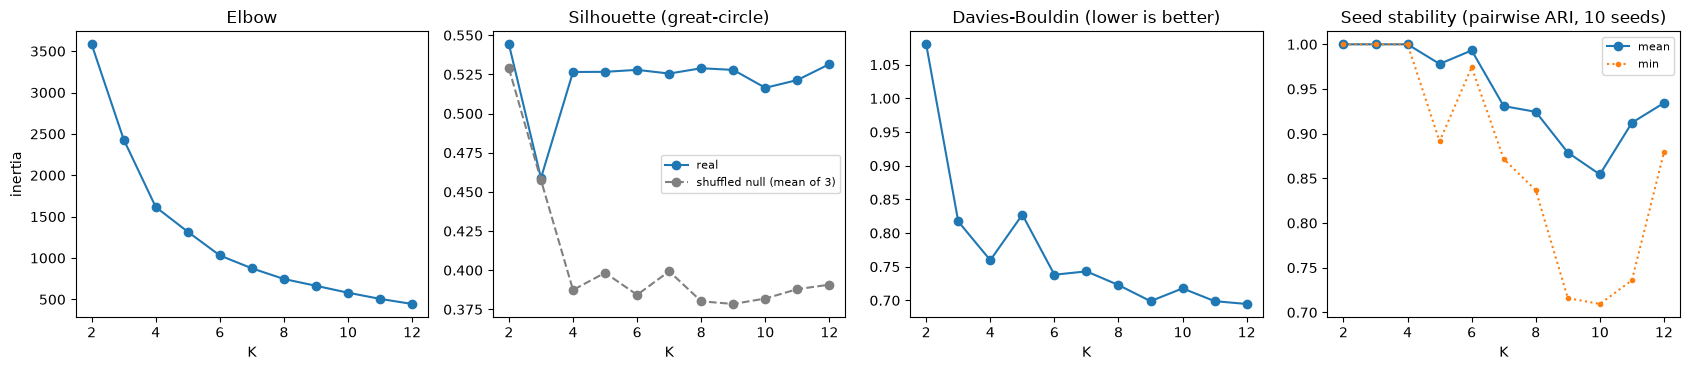

,K,inertia,silhouette,silhouette_null,davies_bouldin,smallest_cluster,largest_cluster,silhouette_minus_null,seed_stability_ari,seed_stability_min_ari
0,2,3582.843,0.544,0.529,1.080,2109,5534,0.015,1.000,1.000
1,3,2432.297,0.459,0.458,0.817,1585,3907,0.001,1.000,1.000
2,4,1616.065,0.527,0.387,0.760,999,3466,0.139,1.000,1.000
3,5,1317.259,0.527,0.398,0.827,763,3336,0.128,0.978,0.891
4,6,1030.710,0.528,0.384,0.738,490,2367,0.144,0.993,0.974
5,7,875.190,0.526,0.399,0.743,336,2332,0.126,0.931,0.872
6,8,746.188,0.529,0.380,0.723,264,2072,0.149,0.924,0.837
7,9,664.062,0.528,0.378,0.699,240,1965,0.149,0.879,0.716
8,10,580.548,0.516,0.382,0.718,308,1665,0.134,0.854,0.709
9,11,505.880,0.521,0.388,0.699,207,1803,0.133,0.912,0.736


In [3]:
K_VALUES = range(2, 13)
rows = []
for k in K_VALUES:
    model = KMeans(k, n_init=10, random_state=SEED).fit(U)
    real = evaluate(R, U, model.labels_, SILHOUETTE_SAMPLE, SEED)
    null = [evaluate(Rn, Un, KMeans(k, n_init=10, random_state=SEED).fit_predict(Un), SILHOUETTE_SAMPLE, SEED)["silhouette"] for Rn, Un in shuffled]
    sizes = np.bincount(model.labels_)
    rows.append(
        {"K": k, "inertia": model.inertia_, "silhouette": real["silhouette"], "silhouette_null": np.mean(null),
         "davies_bouldin": real["davies_bouldin"], "smallest_cluster": sizes.min(), "largest_cluster": sizes.max()}
    )
k_selection = pd.DataFrame(rows)
k_selection["silhouette_minus_null"] = k_selection["silhouette"] - k_selection["silhouette_null"]

stability = []
for k in K_VALUES:
    runs = [KMeans(k, n_init=10, random_state=seed).fit_predict(U) for seed in range(10)]
    scores = pairwise_ari(runs)
    stability.append({"K": k, "seed_stability_ari": scores.mean(), "seed_stability_min_ari": scores.min()})
k_selection = k_selection.merge(pd.DataFrame(stability), on="K")
k_selection.to_csv(RESULTS / "kmeans_k_selection.csv", index=False)

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
axes[0].plot(k_selection["K"], k_selection["inertia"], marker="o")
axes[0].set(title="Elbow", xlabel="K", ylabel="inertia")
axes[1].plot(k_selection["K"], k_selection["silhouette"], marker="o", label="real")
axes[1].plot(k_selection["K"], k_selection["silhouette_null"], marker="o", color="grey", linestyle="--", label="shuffled null (mean of 3)")
axes[1].set(title="Silhouette (great-circle)", xlabel="K")
axes[1].legend(fontsize=8)
axes[2].plot(k_selection["K"], k_selection["davies_bouldin"], marker="o")
axes[2].set(title="Davies-Bouldin (lower is better)", xlabel="K")
axes[3].plot(k_selection["K"], k_selection["seed_stability_ari"], marker="o", label="mean")
axes[3].plot(k_selection["K"], k_selection["seed_stability_min_ari"], marker=".", linestyle=":", label="min")
axes[3].set(title="Seed stability (pairwise ARI, 10 seeds)", xlabel="K")
axes[3].legend(fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES / "kmeans_k_selection.png", dpi=150)
plt.show()
k_selection

**Observations**

- **No clear elbow.** Inertia falls by 32% from K=2 to 3 and 34% from 3 to 4, then 19% (K=5), 22% (K=6) and 11% to 15% per step after that.
- **K=2 and K=3 are no better than the null** (silhouette 0.544 vs 0.529, and 0.459 vs 0.458). These splits follow the distribution of latitude and longitude on their own, which the shuffled null keeps.
- **From K=4 the silhouette is flat:** 0.516 to 0.532 for K = 4 to 12, while the null stays at 0.378 to 0.399 (gap 0.126 to 0.149). Silhouette cannot choose among K of 4 or more; the belts are continuous, so each extra centre cuts them at a different place with a similar score.
- **Davies-Bouldin** has local minima at K=4 (0.760) and K=6 (0.738); K=5 is worse (0.827); the lowest is 0.695 at K=12.
- **Seed stability** is 1.000 for K = 2 to 4 and 0.993 at K=6 (worst pair 0.974). K=5 is 0.978 (worst 0.891), and K = 7 to 11 fall to 0.854 to 0.934 with worst pairs down to 0.709 (K=10).
- **Decision: K=6.** It is the most stable K above 4, with silhouette 0.528 vs null 0.384 (gap 0.144, within 0.005 of the largest gap), Davies-Bouldin 0.738 (lower than K=4) and smallest cluster 490 earthquakes. **K=4** (seed ARI 1.000, gap 0.139) is reported as the fully stable alternative.

In [4]:
CHOSEN_K = 6  # justified in the observations above; K=4 is the fully stable alternative

## 3. K-means: initialization ablation (random vs K-means++)

K-means++ changes one component of K-means: how the first centres are picked. To isolate its effect,
run each initialization 20 times (seeds 0 to 19) with **one** start each (`n_init=1`) at K=6.
- **Inertia gap:** % above the best inertia found by any of the 40 runs (0 = found the best solution).
- **Iterations** to converge.
- **Seed agreement:** pairwise ARI between the 20 runs (1 = every seed gives the same clusters).

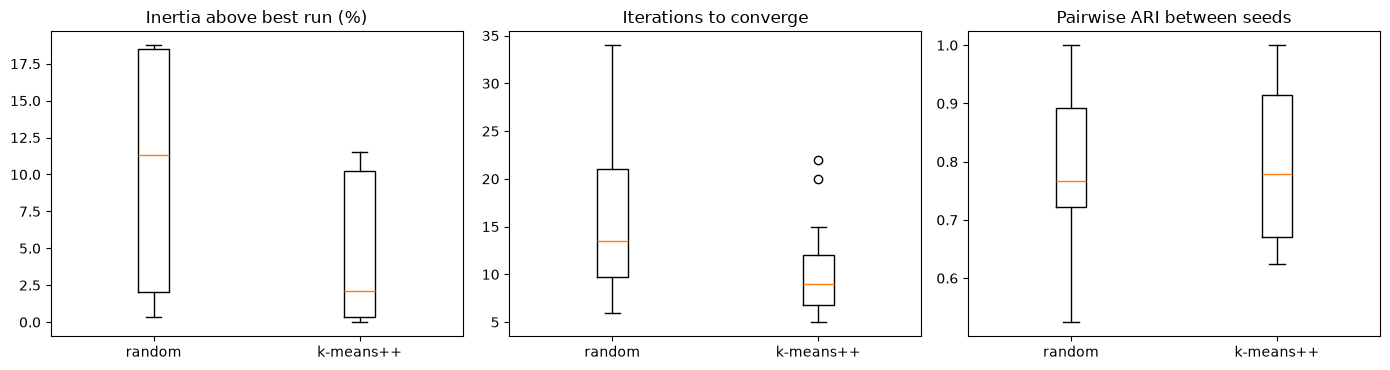

,mean_gap_pct,worst_gap_pct,runs_within_0_1_pct,mean_iterations,mean_seconds,seed_agreement_ari
init,,,,,,
random,10.889,18.758,0,15.25,0.005,0.784
k-means++,4.797,11.540,4,10.30,0.004,0.804


In [5]:
N_SEEDS = 20
rows, label_runs = [], {}
for init, factory in (("random", methods.kmeans_random), ("k-means++", methods.kmeans_plus_plus)):
    runs = []
    for seed in range(N_SEEDS):
        model = factory(CHOSEN_K, seed=seed)
        labels, seconds = timed_fit_predict(model, U)
        rows.append({"init": init, "seed": seed, "inertia": model.inertia_, "iterations": model.n_iter_, "seconds": seconds})
        runs.append(labels)
    label_runs[init] = runs
ablation = pd.DataFrame(rows)
ablation["inertia_gap_%"] = 100 * (ablation["inertia"] / ablation["inertia"].min() - 1)
ablation.to_csv(RESULTS / "kmeans_init_ablation.csv", index=False)

inits = ["random", "k-means++"]
ablation_summary = ablation.groupby("init").agg(
    mean_gap_pct=("inertia_gap_%", "mean"),
    worst_gap_pct=("inertia_gap_%", "max"),
    runs_within_0_1_pct=("inertia_gap_%", lambda gap: int((gap <= 0.1).sum())),
    mean_iterations=("iterations", "mean"),
    mean_seconds=("seconds", "mean"),
).reindex(inits)
ablation_summary["seed_agreement_ari"] = [pairwise_ari(label_runs[init]).mean() for init in inits]
ablation_summary.to_csv(RESULTS / "kmeans_init_ablation_summary.csv")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].boxplot([ablation.loc[ablation["init"] == i, "inertia_gap_%"] for i in inits], tick_labels=inits)
axes[0].set(title="Inertia above best run (%)")
axes[1].boxplot([ablation.loc[ablation["init"] == i, "iterations"] for i in inits], tick_labels=inits)
axes[1].set(title="Iterations to converge")
axes[2].boxplot([pairwise_ari(label_runs[i]) for i in inits], tick_labels=inits)
axes[2].set(title="Pairwise ARI between seeds")
plt.tight_layout()
fig.savefig(FIGURES / "kmeans_init_ablation.png", dpi=150)
plt.show()
ablation_summary

**Observations**

- **K-means++ reaches better solutions from one start.** Random initialization ends on average 10.9% above the best inertia (worst 18.8%) and none of its 20 runs comes within 0.1% of the best. K-means++ ends 4.8% above on average (worst 11.5%), and 4 of 20 runs are within 0.1%.
- **K-means++ converges in fewer iterations:** 10.3 on average against 15.3. Both take well under 0.01 s per run, so the saving does not matter in time at this size.
- **Neither is stable from a single start:** mean pairwise ARI between seeds is 0.784 (random) and 0.804 (K-means++), against 0.993 with 10 starts at the same K (section 2). The box plot shows the lowest pair at about 0.52 for random and about 0.62 for K-means++.
- On this data K-means++ improves both the typical and the worst run. On the LTA train profiles it improved only the worst case (`../sc4020-clustering/notebooks/lta/clustering.ipynb`, section 3).
- **Decision:** final K-means models use K-means++ with `n_init=10`.

## 4. K-means: clusters on the map

Final model: K-means++ with 10 starts at K=6, clusters numbered from largest to smallest.
Each cluster is described by its centre on the sphere, the distance of its earthquakes to that centre,
and its most common regions.

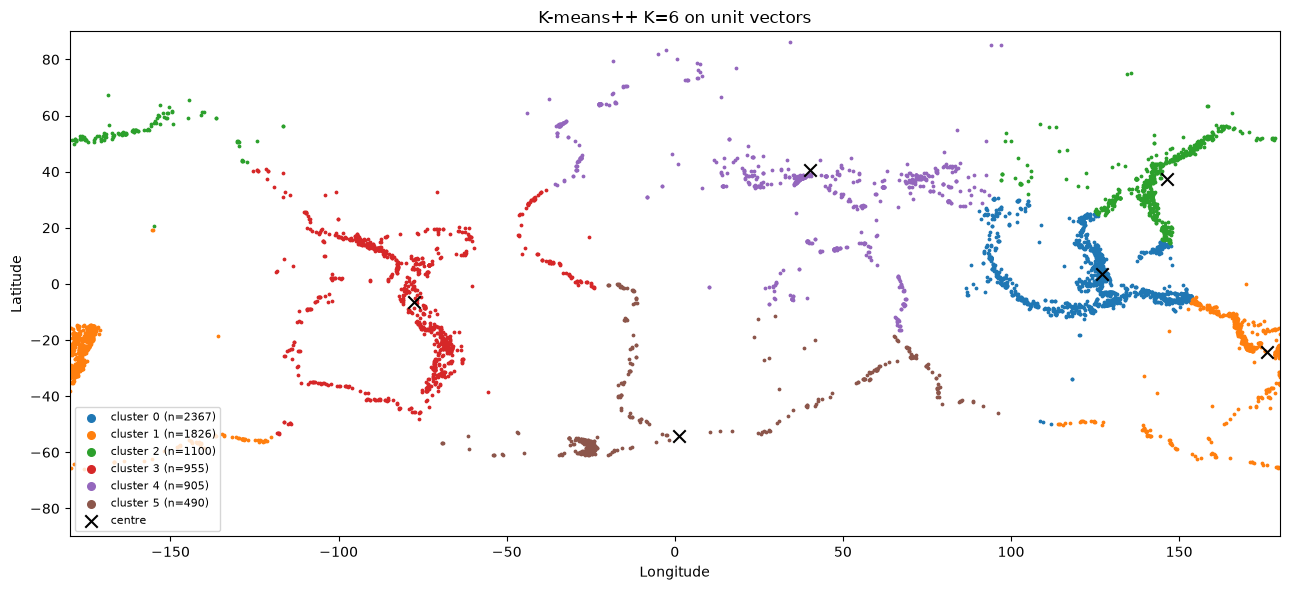

,cluster,events,% of events,centre latitude,centre longitude,median km to centre,95th percentile km to centre,median depth km,top regions
0,0,2367,30.970,3.664,126.921,1174.870,3687.997,35.000,"Philippines (793), Indonesia (760), Papua New Guinea (336)"
1,1,1826,23.891,-24.221,176.258,933.190,4419.137,11.253,"Tonga (348), Vanuatu (243), the Loyalty Islands (207)"
2,2,1100,14.392,37.346,146.283,1480.762,4385.489,13.373,"Japan region (306), Japan (279), Northern Mariana Islands (146)"
3,3,955,12.495,-6.288,-77.706,2612.785,5574.580,23.945,"Chile (160), Peru (97), Mexico (86)"
4,4,905,11.841,40.507,40.111,2833.480,5630.386,10.000,"Turkey (184), Reykjanes Ridge (86), Afghanistan (61)"
5,5,490,6.411,-54.171,1.349,1827.682,6370.111,10.000,"South Sandwich Islands region (248), southern Mid-Atlantic Ridge (48), Mid-Indian Ridg..."


In [6]:
kmeans_labels = relabel_by_size(KMeans(CHOSEN_K, n_init=10, random_state=SEED).fit_predict(U))
pd.DataFrame({"id": events["id"], "cluster": kmeans_labels}).to_csv(RESULTS / "kmeans_labels.csv", index=False)
kmeans_summary = cluster_summary(events, kmeans_labels)
kmeans_summary.to_csv(RESULTS / "kmeans_cluster_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(13, 6))
for cluster in range(CHOSEN_K):
    members = kmeans_labels == cluster
    ax.scatter(events.loc[members, "longitude"], events.loc[members, "latitude"], s=3, color=plt.cm.tab10(cluster), label=f"cluster {cluster} (n={members.sum()})")
ax.scatter(kmeans_summary["centre longitude"], kmeans_summary["centre latitude"], marker="x", s=80, color="black", label="centre")
ax.set(xlim=(-180, 180), ylim=(-90, 90), xlabel="Longitude", ylabel="Latitude", title=f"K-means++ K={CHOSEN_K} on unit vectors")
legend = ax.legend(fontsize=8, loc="lower left")
for handle in legend.legend_handles[:-1]:
    handle.set_sizes([30])
plt.tight_layout()
fig.savefig(FIGURES / "kmeans_cluster_map.png", dpi=150)
plt.show()
kmeans_summary

In [7]:
k4_labels = relabel_by_size(KMeans(4, n_init=10, random_state=SEED).fit_predict(U))
print(f"ARI between K=4 and K={CHOSEN_K}: {adjusted_rand_score(k4_labels, kmeans_labels):.3f}")
pd.crosstab(k4_labels, kmeans_labels, rownames=["K=4 cluster"], colnames=[f"K={CHOSEN_K} cluster"])

ARI between K=4 and K=6: 0.713


K=6 cluster,0,1,2,3,4,5
K=4 cluster,,,,,,
0,2357,0,1079,0,2,28
1,10,1814,1,0,0,0
2,0,12,14,955,0,372
3,0,0,6,0,903,90


**Observations**

- **K-means clusters are large regions, not belts.** The median distance from an earthquake to its cluster centre is 933 to 2,833 km, and the 95th percentile 3,688 to 6,370 km.
- The six clusters (largest first):
  - 0 (2,367, 31.0%): the Philippines, Indonesia and Papua New Guinea;
  - 1 (1,826): Tonga, Vanuatu and the Loyalty Islands. It appears at both the left and right map edges and stays one cluster, because unit vectors have no 180 degree line;
  - 2 (1,100): Japan and the Northern Mariana Islands, plus the Aleutians and Alaska at the top left;
  - 3 (955): Chile, Peru and Mexico, with the ocean lines of the eastern Pacific;
  - 4 (905): Turkey, the Reykjanes Ridge and Afghanistan. It joins the belt from the Mediterranean to Asia with the North Atlantic and western Indian Ocean lines, which are thousands of km apart;
  - 5 (490): the South Sandwich Islands and the southern Atlantic and Indian Ocean lines.
- The busiest areas get the smallest clusters in km, and the sparse ocean lines are absorbed into whichever centre is nearest.
- **K=4 vs K=6** (ARI 0.713): K=6 mostly splits K=4 clusters. K=4 cluster 0 becomes K=6 clusters 0 (2,357) and 2 (1,079); K=4 cluster 2 becomes clusters 3 (955) and 5 (372).

## 5. DBSCAN: choosing eps and min_samples

DBSCAN needs a radius `eps` (here in km on the Earth's surface) and a minimum neighbourhood size
`min_samples`. The **k-distance plot** sorts every earthquake's distance to its (min_samples - 1)-th
nearest other earthquake. A sharp knee would separate dense areas (below) from sparse ones (above) and
suggest eps. The uniform null is drawn for comparison.

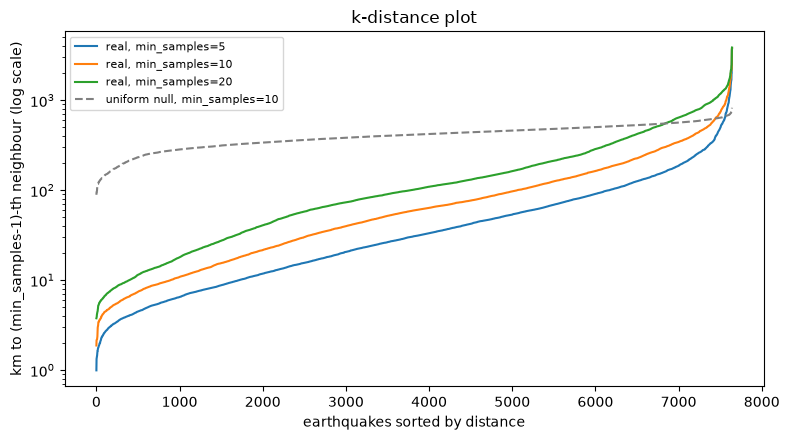

In [8]:
MIN_SAMPLES = (5, 10, 20)
fig, ax = plt.subplots(figsize=(8, 4.5))
for m in MIN_SAMPLES:
    ax.plot(k_distances_km(events["latitude"], events["longitude"], m), label=f"real, min_samples={m}")
ax.plot(k_distances_km(uniform_degrees[:, 0], uniform_degrees[:, 1], 10), color="grey", linestyle="--", label="uniform null, min_samples=10")
ax.set(yscale="log", title="k-distance plot", xlabel="earthquakes sorted by distance", ylabel="km to (min_samples-1)-th neighbour (log scale)")
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES / "dbscan_k_distance.png", dpi=150)
plt.show()

Grid: for each `min_samples`, eps is set at the 25th, 50th, 75th, 90th and 95th percentile of that k-distance curve.

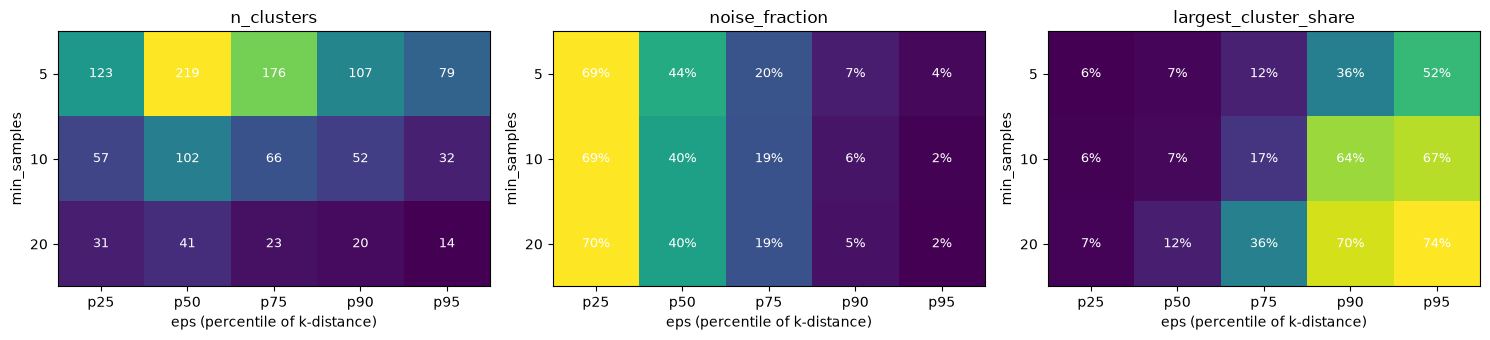

,min_samples,eps_quantile,eps_km,seconds,n_clusters,noise_fraction,largest_cluster_share,silhouette,davies_bouldin
0,5,0.25,11.228,0.042,123,0.694,0.060,0.632,0.267
1,5,0.50,30.850,0.046,219,0.436,0.068,0.646,0.306
2,5,0.75,78.805,0.050,176,0.197,0.122,0.383,0.368
3,5,0.90,168.030,0.057,107,0.073,0.355,0.025,0.473
4,5,0.95,265.573,0.062,79,0.036,0.516,0.143,0.454
5,10,0.25,20.440,0.044,57,0.694,0.065,0.878,0.187
6,10,0.50,59.712,0.049,102,0.405,0.074,0.660,0.349
7,10,0.75,140.491,0.055,66,0.190,0.166,0.376,0.336
8,10,0.90,312.113,0.063,52,0.059,0.638,0.169,0.453
9,10,0.95,455.512,0.069,32,0.025,0.667,0.247,0.536


In [9]:
EPS_QUANTILES = (0.25, 0.5, 0.75, 0.9, 0.95)
rows = []
for m in MIN_SAMPLES:
    distances = k_distances_km(events["latitude"], events["longitude"], m)
    for q in EPS_QUANTILES:
        eps_km = float(np.quantile(distances, q))
        labels, seconds = timed_fit_predict(methods.dbscan(eps_km, m), R)
        rows.append({"min_samples": m, "eps_quantile": q, "eps_km": eps_km, "seconds": seconds, **evaluate(R, U, labels, SILHOUETTE_SAMPLE, SEED)})
dbscan_grid = pd.DataFrame(rows)
dbscan_grid.to_csv(RESULTS / "dbscan_grid.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, (metric, fmt) in zip(axes, (("n_clusters", "{:.0f}"), ("noise_fraction", "{:.0%}"), ("largest_cluster_share", "{:.0%}"))):
    grid = dbscan_grid.pivot(index="min_samples", columns="eps_quantile", values=metric)
    ax.imshow(grid.to_numpy(), cmap="viridis", aspect="auto")
    ax.set(xticks=range(len(grid.columns)), xticklabels=[f"p{int(q * 100)}" for q in grid.columns], yticks=range(len(grid.index)), yticklabels=grid.index,
           xlabel="eps (percentile of k-distance)", ylabel="min_samples", title=metric)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            ax.text(j, i, fmt.format(grid.iat[i, j]), ha="center", va="center", color="white", fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES / "dbscan_grid.png", dpi=150)
plt.show()
dbscan_grid

**Observations**

- **No knee.** The real k-distance curves rise smoothly on the log scale from about 1 to over 1,000 km. The uniform null curve is flat by comparison (about 100 to 800 km). The real curves lie below the null for most earthquakes and cross it only for the sparsest few hundred (min_samples=10) to roughly 800 (min_samples=20): density varies continuously, so there is no single distance that separates dense from sparse.
- **Every eps is a trade-off:**
  - at the 25th percentile (eps 11 to 38 km), 69% to 70% of earthquakes are noise;
  - at the 50th percentile (31 to 102 km), noise is 40% to 44% with 41 to 219 clusters;
  - at the 90th and 95th percentiles noise drops to 2% to 7%, but the largest cluster holds 36% to 74% of all earthquakes: neighbouring belts chain into one cluster.
- **Small `min_samples` fragments the belts:** `min_samples=5` gives 79 to 219 clusters.
- **Selection** (at least 2 clusters, at most 50% noise, highest silhouette): `min_samples=20`, eps 101.8 km (50th percentile): 41 clusters, 40.4% noise, largest cluster 11.8%, silhouette 0.703. That silhouette describes only the 59.6% of earthquakes that were clustered.
- Each fit takes under 0.1 s.

## 6. HDBSCAN: parameter grid

HDBSCAN removes the single global eps: it builds a hierarchy of density levels and keeps the clusters
that persist. `min_cluster_size` is scaled to about 7,600 earthquakes (25, 50, 100); `min_samples`
(how conservative the density estimate is) is the default (equal to `min_cluster_size`), 5 or 10.
Each setting is also run on the uniform null.

In [10]:
MIN_CLUSTER_SIZES = (25, 50, 100)
rows = []
for mcs in MIN_CLUSTER_SIZES:
    for ms in (None, 5, 10):
        for data_name, (Rd, Ud) in (("real", (R, U)), ("uniform null", (R_uniform, U_uniform))):
            labels, seconds = timed_fit_predict(methods.hdbscan(mcs, ms), Rd)
            scores = evaluate(Rd, Ud, labels, SILHOUETTE_SAMPLE, SEED)
            sizes = sorted(np.bincount(labels[labels != NOISE_LABEL]).tolist(), reverse=True) if scores["n_clusters"] else []
            rows.append(
                {"data": data_name, "min_cluster_size": mcs, "min_samples": "default" if ms is None else ms,
                 "seconds": seconds, "largest_5_sizes": sizes[:5], **scores}
            )
hdbscan_grid = pd.DataFrame(rows)
hdbscan_grid.to_csv(RESULTS / "hdbscan_grid.csv", index=False)
hdbscan_grid

,data,min_cluster_size,min_samples,seconds,largest_5_sizes,n_clusters,noise_fraction,largest_cluster_share,silhouette,davies_bouldin
0,real,25,default,1.053,"[821, 554, 418, 309, 291]",47,0.227,0.107,0.655,0.351
1,uniform null,25,default,1.099,"[1828, 181, 162, 135, 93]",20,0.590,0.239,0.338,0.542
2,real,25,5,1.012,"[576, 272, 241, 230, 207]",88,0.200,0.075,0.643,0.474
3,uniform null,25,5,1.055,"[622, 213, 121, 109, 92]",74,0.437,0.081,0.336,0.773
4,real,25,10,1.055,"[560, 300, 268, 257, 239]",75,0.224,0.073,0.656,0.434
5,uniform null,25,10,1.072,"[1927, 781, 202, 164, 104]",29,0.449,0.252,0.017,0.830
6,real,50,default,1.082,"[575, 427, 391, 299, 294]",28,0.307,0.075,0.757,0.329
7,uniform null,50,default,1.136,"[2618, 1585, 71, 62]",4,0.433,0.343,0.320,0.727
8,real,50,5,1.012,"[576, 381, 356, 337, 332]",42,0.179,0.075,0.608,0.479
9,uniform null,50,5,1.056,"[1063, 233, 213, 182, 153]",29,0.504,0.139,0.304,0.791


**Observations**

- **Real data:** 15 to 88 clusters, 17.9% to 41.0% noise, largest cluster 7.3% to 10.7% of earthquakes, silhouette 0.608 to 0.757.
- **The uniform null also forms clusters** (2 to 74, with 27.5% to 51.9% noise), because HDBSCAN always finds relatively denser patches in random points. They differ from the real clusters:
  - the largest null cluster holds 8.1% to 38.6% of points, and more than 13% in 8 of 9 settings, against at most 10.7% on real data;
  - the null silhouette (0.017 to 0.598) is lower than the real one in all 9 settings.
- Real data has less noise than the null in 8 of 9 settings. The exception is `min_cluster_size=100` with default `min_samples` (41.0% vs 39.9%), where real data still has 15 clusters against 2.
- **`min_samples` of 5 or 10** lowers noise and adds clusters but lowers silhouette: at `min_cluster_size=50`, noise goes from 30.7% (default) to 17.9% and 21.4%, and silhouette from 0.757 to 0.608 and 0.627.
- **Selection** (same rule as DBSCAN): `min_cluster_size=50`, default `min_samples`: 28 clusters, 30.7% noise, largest cluster 7.5%, silhouette 0.757. Compared with the chosen DBSCAN, HDBSCAN keeps more earthquakes (69.3% vs 59.6%) with a higher silhouette (0.757 vs 0.703).
- Each fit takes about 1 s, roughly 20 times as long as DBSCAN.

## 7. What the density-based clusters contain

For each density method, the setting chosen by the rule in `../AGENTS.md`: at least 2 clusters, at most
50% noise, highest silhouette (`best_density_setting`). Clusters are numbered from largest to smallest.
With 28 to 41 clusters the map colours repeat; the 10 largest clusters are labelled at their centres.

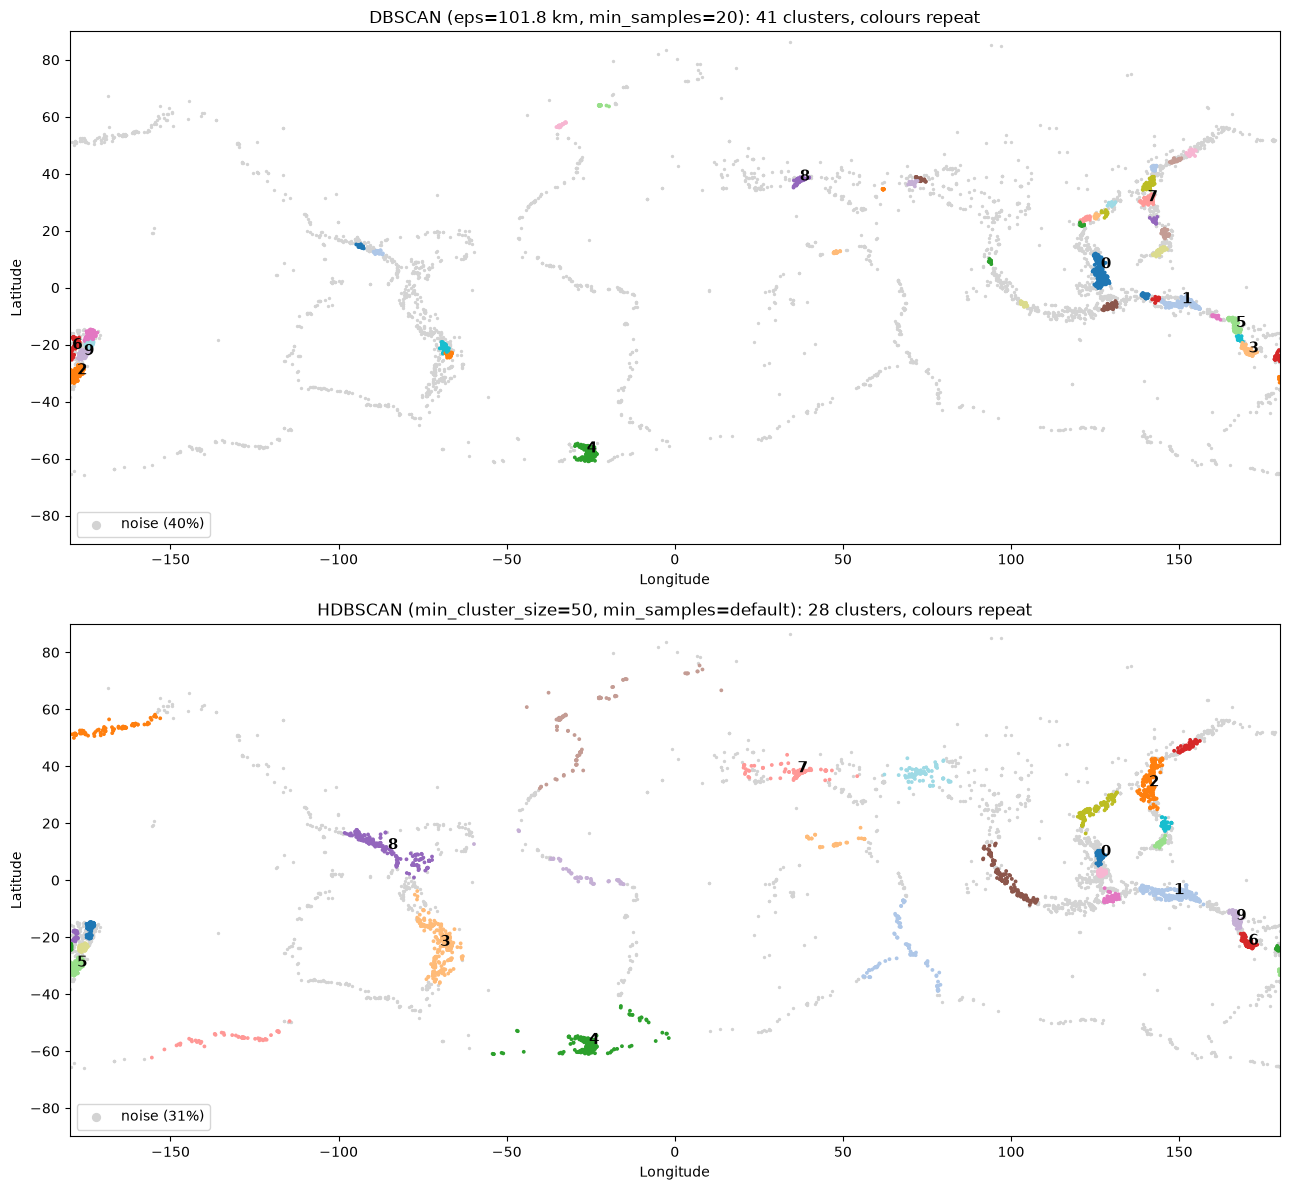

**DBSCAN: 10 largest clusters**

,cluster,events,% of events,centre latitude,centre longitude,median km to centre,95th percentile km to centre,median depth km,top regions
0,0,901,11.789,6.824,126.725,217.965,578.881,50.345,"Philippines (671), Indonesia (208), Molucca Sea (19)"
1,1,295,3.860,-5.449,150.854,274.737,600.155,40.281,"Papua New Guinea (289), Solomon Islands (6)"
2,2,292,3.820,-30.379,-177.794,148.704,308.074,18.545,"Kermadec Islands region (136), New Zealand (109), the Kermadec Islands (47)"
3,3,279,3.650,-22.737,170.632,64.150,294.206,10.000,"the Loyalty Islands (206), New Caledonia (44), Vanuatu (29)"
4,4,244,3.192,-57.841,-26.185,188.496,319.040,35.000,South Sandwich Islands region (244)
5,5,227,2.970,-13.805,166.892,149.041,368.478,33.385,"Vanuatu (174), Solomon Islands (45), Santa Cruz Islands (7)"
6,6,212,2.774,-21.539,-179.197,284.510,463.552,546.118,"the Fiji Islands (100), Fiji region (55), Fiji (43)"
7,7,210,2.748,30.380,140.589,92.423,232.493,10.000,Japan region (210)
8,8,200,2.617,37.637,37.162,78.997,207.458,10.000,"Turkey (169), Central Turkey (17), eastern Turkey (6)"
9,9,184,2.407,-23.623,-175.724,67.733,196.753,10.000,"Tonga (144), the Fiji Islands (25), Tonga region (15)"


**HDBSCAN: 10 largest clusters**

,cluster,events,% of events,centre latitude,centre longitude,median km to centre,95th percentile km to centre,median depth km,top regions
0,0,575,7.523,8.542,126.711,34.337,174.371,52.534,"Philippines (572), Philippine Islands region (3)"
1,1,427,5.587,-4.889,148.496,411.252,981.768,33.230,"Papua New Guinea (364), Indonesia (54), Solomon Islands (7)"
2,2,391,5.116,33.012,141.019,360.284,989.136,10.000,"Japan region (246), Japan (145)"
3,3,299,3.912,-23.084,-69.790,601.991,1315.823,106.733,"Chile (132), Argentina (81), Peru (66)"
4,4,294,3.847,-57.502,-25.498,212.159,1451.122,29.576,"South Sandwich Islands region (248), southern Mid-Atlantic Ridge (17), the South Sandw..."
5,5,291,3.807,-30.368,-177.787,146.484,308.938,18.266,"Kermadec Islands region (136), New Zealand (109), the Kermadec Islands (46)"
6,6,283,3.703,-22.664,170.615,71.471,294.276,10.000,"the Loyalty Islands (206), New Caledonia (44), Vanuatu (33)"
7,7,246,3.219,37.914,36.506,129.531,1190.654,10.000,"Turkey (184), Central Turkey (17), Greece (12)"
8,8,234,3.062,10.927,-85.339,778.061,1432.631,35.000,"Mexico (51), Colombia (49), Panama (35)"
9,9,227,2.970,-13.951,166.978,135.882,350.680,33.385,"Vanuatu (180), Solomon Islands (40), Santa Cruz Islands (7)"


In [11]:
MAX_NOISE = 0.5
# tab20 without its two greys (indices 14 and 15), so no cluster is drawn in the same colour as noise
PALETTE = [colour for index, colour in enumerate(plt.cm.tab20.colors) if index not in (14, 15)]
best_dbscan = best_density_setting(dbscan_grid, MAX_NOISE)
best_hdbscan = best_density_setting(hdbscan_grid, MAX_NOISE)
HDBSCAN_MIN_SAMPLES = None if best_hdbscan["min_samples"] == "default" else int(best_hdbscan["min_samples"])
density_models = {
    "DBSCAN": (lambda: methods.dbscan(best_dbscan["eps_km"], int(best_dbscan["min_samples"])),
               f"eps={best_dbscan['eps_km']:.1f} km, min_samples={int(best_dbscan['min_samples'])}"),
    "HDBSCAN": (lambda: methods.hdbscan(int(best_hdbscan["min_cluster_size"]), HDBSCAN_MIN_SAMPLES),
                f"min_cluster_size={int(best_hdbscan['min_cluster_size'])}, min_samples={best_hdbscan['min_samples']}"),
}
density_labels = {name: relabel_by_size(make().fit_predict(R)) for name, (make, _) in density_models.items()}
density_summaries = {name: cluster_summary(events, labels) for name, labels in density_labels.items()}
for name, labels in density_labels.items():
    pd.DataFrame({"id": events["id"], "cluster": labels}).to_csv(RESULTS / f"{name.lower()}_labels.csv", index=False)
    density_summaries[name].to_csv(RESULTS / f"{name.lower()}_cluster_summary.csv", index=False)

fig, axes = plt.subplots(2, 1, figsize=(13, 12))
for ax, (name, labels) in zip(axes, density_labels.items()):
    noise = labels == NOISE_LABEL
    ax.scatter(events.loc[noise, "longitude"], events.loc[noise, "latitude"], s=2, color="lightgrey", label=f"noise ({noise.mean():.0%})")
    ax.scatter(events.loc[~noise, "longitude"], events.loc[~noise, "latitude"], s=3, color=[PALETTE[label % len(PALETTE)] for label in labels[~noise]])
    for _, row in density_summaries[name].head(10).iterrows():
        ax.annotate(str(int(row["cluster"])), (row["centre longitude"], row["centre latitude"]), fontsize=11, weight="bold")
    ax.set(xlim=(-180, 180), ylim=(-90, 90), xlabel="Longitude", ylabel="Latitude",
           title=f"{name} ({density_models[name][1]}): {labels.max() + 1} clusters, colours repeat")
    ax.legend(markerscale=4, loc="lower left")
plt.tight_layout()
fig.savefig(FIGURES / "density_cluster_maps.png", dpi=150)
plt.show()

for name, summary in density_summaries.items():
    display(Markdown(f"**{name}: 10 largest clusters**"))
    display(summary.head(10))

### Which earthquakes become noise?

Noise should be the isolated earthquakes. The distance to the nearest other earthquake (EDA section 6)
is compared for noise and clustered earthquakes, and the share of each region's earthquakes that is
clustered is compared between the two methods (regions with at least 100 earthquakes).

In [12]:
nearest = nearest_neighbour_km(events["latitude"], events["longitude"])
display(pd.DataFrame({
    name: {
        "noise earthquakes": int((labels == NOISE_LABEL).sum()),
        "median km to nearest earthquake, noise": float(np.median(nearest[labels == NOISE_LABEL])),
        "median km to nearest earthquake, clustered": float(np.median(nearest[labels != NOISE_LABEL])),
    }
    for name, labels in density_labels.items()
}))

regions = region_from_place(events["place"])
by_region = pd.DataFrame({"earthquakes": regions.value_counts()})
for name, labels in density_labels.items():
    by_region[f"{name} clustered %"] = 100 * pd.Series(labels != NOISE_LABEL, index=events.index).groupby(regions).mean()
by_region = by_region[by_region["earthquakes"] >= 100]
by_region["HDBSCAN minus DBSCAN"] = by_region["HDBSCAN clustered %"] - by_region["DBSCAN clustered %"]
by_region.sort_values("HDBSCAN minus DBSCAN", ascending=False)

,DBSCAN,HDBSCAN
noise earthquakes,3084.000,2347.000
"median km to nearest earthquake, noise",23.816,20.009
"median km to nearest earthquake, clustered",6.280,7.254


,earthquakes,DBSCAN clustered %,HDBSCAN clustered %,HDBSCAN minus DBSCAN
place,,,,
Alaska,120,0.000,74.167,74.167
Chile,160,37.500,82.500,45.000
Japan,309,63.754,81.230,17.476
Papua New Guinea,378,86.243,96.296,10.053
Indonesia,760,45.658,54.211,8.553
Turkey,184,91.848,100.000,8.152
South Sandwich Islands region,248,98.387,100.000,1.613
Northern Mariana Islands,160,81.875,82.500,0.625
Kermadec Islands region,140,97.143,97.143,0.000


**Observations**

- **DBSCAN keeps compact patches only.** Its clusters are dense spots, mostly in the western Pacific, Turkey and the South Sandwich Islands. Alaska, most of the Americas and nearly all of the ocean lines are noise. Its largest cluster (901 earthquakes) joins the Philippines (671) and Indonesia (208).
- **HDBSCAN also keeps long, sparser belt segments:** Alaska and the Aleutians, Chile, Argentina and Peru (cluster 3, median 602 km to centre), Mexico to Panama (cluster 8, median 778 km), and segments of the ocean lines in the Atlantic, Indian and southern Pacific oceans. Its largest cluster is the Philippines alone (575 earthquakes, median 34 km to centre).
- **Aftershock sequences form their own clusters** in both methods: Turkey (DBSCAN cluster 8, 200 earthquakes; HDBSCAN cluster 7, 246) and the Philippines (EDA section 9).
- **Noise is sparser than clustered earthquakes but not isolated.** The median distance to the nearest other earthquake is 23.8 km (DBSCAN noise) and 20.0 km (HDBSCAN noise), against 6.3 and 7.3 km for clustered earthquakes. The most isolated earthquakes in the EDA were over 800 km from any other, so noise includes whole sparse belts, not only isolated events.
- **HDBSCAN clusters more of the sparse belts:** Alaska goes from 0% clustered (DBSCAN) to 74.2%, Chile from 37.5% to 82.5%, and Japan from 63.8% to 81.2%.
- **But less of some dense areas:** the Solomon Islands go from 70.3% to 39.8%, the Fiji Islands from 84.5% to 58.8%, Tonga from 94.8% to 69.5% and the Philippines from 84.6% to 75.2%. HDBSCAN extracts each cluster at its own density level, so earthquakes around a very dense core can fall below that level and become noise, even though a fixed 102 km radius includes them.

## 8. Method comparison

One setting per method:
- **K-means (random)** and **K-means++**: K=6, one start (`n_init=1`), seed 0, so the initialization difference is visible.
- **DBSCAN** and **HDBSCAN**: the settings from section 7.

Each run is repeated on its null (shuffled null for K-means, uniform null for density methods) with the
same setting. Agreement between methods is the ARI of their labels, with noise counted as one more group.

In [13]:
settings = {
    "K-means (random)": (lambda: methods.kmeans_random(CHOSEN_K, seed=SEED), f"K={CHOSEN_K}, n_init=1"),
    "K-means++": (lambda: methods.kmeans_plus_plus(CHOSEN_K, seed=SEED), f"K={CHOSEN_K}, n_init=1"),
    **density_models,
}
rows, comparison_labels = [], {}
for name, (make, setting) in settings.items():
    uses_unit_vectors = name.startswith("K-means")
    labels, seconds = timed_fit_predict(make(), U if uses_unit_vectors else R)
    null_R, null_U = shuffled[0] if uses_unit_vectors else (R_uniform, U_uniform)
    null_scores = evaluate(null_R, null_U, make().fit_predict(null_U if uses_unit_vectors else null_R), SILHOUETTE_SAMPLE, SEED)
    comparison_labels[name] = labels
    rows.append({
        "method": name, "setting": setting, "seconds": seconds, **evaluate(R, U, labels, SILHOUETTE_SAMPLE, SEED),
        "null": "shuffled" if uses_unit_vectors else "uniform", "null_silhouette": null_scores["silhouette"],
        "null_n_clusters": null_scores["n_clusters"], "null_noise_fraction": null_scores["noise_fraction"],
    })
comparison = pd.DataFrame(rows)
comparison.to_csv(RESULTS / "method_comparison.csv", index=False)

agreement = pd.DataFrame({a: {b: adjusted_rand_score(comparison_labels[a], comparison_labels[b]) for b in comparison_labels} for a in comparison_labels})
agreement.to_csv(RESULTS / "method_agreement.csv")
display(comparison)
display(Markdown("**Agreement (ARI)**"))
agreement

,method,setting,seconds,n_clusters,noise_fraction,largest_cluster_share,silhouette,davies_bouldin,null,null_silhouette,null_n_clusters,null_noise_fraction
0,K-means (random),"K=6, n_init=1",0.004,6,0.000,0.443,0.525,0.800,shuffled,0.389,6,0.000
1,K-means++,"K=6, n_init=1",0.005,6,0.000,0.310,0.528,0.738,shuffled,0.391,6,0.000
2,DBSCAN,"eps=101.8 km, min_samples=20",0.051,41,0.404,0.118,0.703,0.351,uniform,NaN,0,1.000
3,HDBSCAN,"min_cluster_size=50, min_samples=default",1.081,28,0.307,0.075,0.757,0.329,uniform,0.320,4,0.433


**Agreement (ARI)**

,K-means (random),K-means++,DBSCAN,HDBSCAN
K-means (random),1.000,0.732,0.047,0.099
K-means++,0.732,1.000,0.104,0.135
DBSCAN,0.047,0.104,1.000,0.416
HDBSCAN,0.099,0.135,0.416,1.000


### Does K-means cut belts, and does it merge them?

For the 10 largest HDBSCAN clusters (section 7): how many K-means clusters their earthquakes fall into.
For each K-means cluster: how many HDBSCAN clusters it contains, and how much of it HDBSCAN calls noise.

In [14]:
hdbscan_labels = density_labels["HDBSCAN"]
hdbscan_top = density_summaries["HDBSCAN"].set_index("cluster")
rows = []
for cluster in range(10):
    members = hdbscan_labels == cluster
    counts = pd.Series(kmeans_labels[members]).value_counts()
    rows.append({
        "HDBSCAN cluster": cluster, "earthquakes": int(members.sum()), "top regions": hdbscan_top.loc[cluster, "top regions"],
        "K-means clusters it falls into": len(counts), "% in its main K-means cluster": 100 * counts.iloc[0] / members.sum(),
    })
display(pd.DataFrame(rows))

pd.DataFrame({
    "earthquakes": pd.Series(kmeans_labels).value_counts().sort_index(),
    "HDBSCAN clusters inside (at least 10 earthquakes)": [
        int((pd.Series(hdbscan_labels[(kmeans_labels == c) & (hdbscan_labels != NOISE_LABEL)]).value_counts() >= 10).sum()) for c in range(CHOSEN_K)
    ],
    "HDBSCAN noise %": [100 * (hdbscan_labels[kmeans_labels == c] == NOISE_LABEL).mean() for c in range(CHOSEN_K)],
    "top regions": kmeans_summary.set_index("cluster")["top regions"],
}).rename_axis("K-means cluster")

,HDBSCAN cluster,earthquakes,top regions,K-means clusters it falls into,% in its main K-means cluster
0,0,575,"Philippines (572), Philippine Islands region (3)",1,100.000
1,1,427,"Papua New Guinea (364), Indonesia (54), Solomon Islands (7)",2,88.759
2,2,391,"Japan region (246), Japan (145)",1,100.000
3,3,299,"Chile (132), Argentina (81), Peru (66)",1,100.000
4,4,294,"South Sandwich Islands region (248), southern Mid-Atlantic Ridge (17), the South Sandw...",1,100.000
5,5,291,"Kermadec Islands region (136), New Zealand (109), the Kermadec Islands (46)",1,100.000
6,6,283,"the Loyalty Islands (206), New Caledonia (44), Vanuatu (33)",1,100.000
7,7,246,"Turkey (184), Central Turkey (17), Greece (12)",1,100.000
8,8,234,"Mexico (51), Colombia (49), Panama (35)",1,100.000
9,9,227,"Vanuatu (180), Solomon Islands (40), Santa Cruz Islands (7)",1,100.000


,earthquakes,HDBSCAN clusters inside (at least 10 earthquakes),HDBSCAN noise %,top regions
K-means cluster,,,,
0,2367,7,30.925,"Philippines (793), Indonesia (760), Papua New Guinea (336)"
1,1826,9,29.025,"Tonga (348), Vanuatu (243), the Loyalty Islands (207)"
2,1100,5,31.182,"Japan region (306), Japan (279), Northern Mariana Islands (146)"
3,955,3,38.743,"Chile (160), Peru (97), Mexico (86)"
4,905,5,29.613,"Turkey (184), Reykjanes Ridge (86), Afghanistan (61)"
5,490,3,21.224,"South Sandwich Islands region (248), southern Mid-Atlantic Ridge (48), Mid-Indian Ridg..."


**Observations**

- **Single-start K-means:** random and K-means++ (seed 0) have almost the same silhouette (0.525 and 0.528), but random has a larger largest cluster (44.3% vs 31.0%) and a worse Davies-Bouldin (0.800 vs 0.738). Their labels agree at ARI 0.732, in line with section 3: random starts end further from the best solution.
- **Against the nulls:**
  - K-means silhouette is 0.525 to 0.528 against 0.389 to 0.391 on the shuffled null;
  - at the chosen setting DBSCAN finds **no clusters** on the uniform null (100% noise): no uniform area has 20 points within 101.8 km;
  - HDBSCAN finds 4 clusters on the uniform null with 43.3% noise and silhouette 0.320, against 28 clusters, 30.7% noise and 0.757 on real data.
- **Density methods score higher, on fewer earthquakes.** Silhouette is 0.757 (HDBSCAN) and 0.703 (DBSCAN) against 0.528 (K-means++), and Davies-Bouldin 0.329 and 0.351 against 0.738. These are computed on the 69.3% and 59.6% of earthquakes that are clustered, while K-means scores all of them, so the numbers are not a like-for-like ranking.
- **Methods barely agree:** ARI between K-means and a density method is 0.047 to 0.135; DBSCAN vs HDBSCAN is 0.416.
- **The low agreement comes from K-means merging belts, not cutting them.** 9 of the 10 largest HDBSCAN clusters lie entirely inside one K-means cluster; the exception, Papua New Guinea, has 88.8% in one. Each K-means cluster contains 3 to 9 HDBSCAN clusters of at least 10 earthquakes, and 21.2% to 38.7% of its earthquakes are HDBSCAN noise.
- **Runtime:** K-means under 0.01 s per start, DBSCAN about 0.05 s, HDBSCAN about 1 s.

## 9. Summary

| Question | Answer from this notebook |
|---|---|
| Is there cluster structure? | Yes. K-means silhouette is about 0.14 above the shuffled null from K=4 (section 2); DBSCAN finds no clusters on the uniform null at its chosen setting, and HDBSCAN's real clusters have higher silhouette than the null in all 9 settings (sections 6 and 8) |
| What K? | K=6 (seed ARI 0.993, Davies-Bouldin 0.738); silhouette is flat for K of 4 or more, so the choice rests on stability; K=4 (seed ARI 1.000) is the alternative |
| Does K-means++ matter? | Yes, from one start: mean gap 4.8% vs 10.9%, worst 11.5% vs 18.8%, 4 vs 0 runs within 0.1% of the best, 10.3 vs 15.3 iterations. Seed agreement is still only 0.80, so 10 starts are needed |
| What do K-means clusters mean? | Large regions (median 933 to 2,833 km to centre) that each merge several belts, e.g. Turkey with the Reykjanes Ridge and Afghanistan |
| DBSCAN | eps 101.8 km, `min_samples=20`: 41 compact clusters, 40.4% noise. No knee in the k-distance curve: small eps discards most earthquakes, large eps chains belts (largest cluster up to 74%) |
| HDBSCAN | `min_cluster_size=50`: 28 clusters, 30.7% noise, silhouette 0.757. Follows long sparse belts (Alaska 74.2% clustered vs 0% for DBSCAN) but drops earthquakes around very dense cores (Solomon Islands 39.8% vs 70.3%) |
| Success case | HDBSCAN on belts of varying density: separates the Philippines from Indonesia and keeps Chile to Peru and Mexico to Panama as elongated clusters |
| Failure cases | DBSCAN with one eps on continuously varying density (no knee); K-means merging belts thousands of km apart and assigning every sparse earthquake; silhouette unable to choose K |
| Agreement | K-means vs density methods ARI 0.047 to 0.135; 9 of 10 largest HDBSCAN clusters sit inside one K-means cluster |
| Runtime | K-means under 0.01 s per start, DBSCAN about 0.05 s, HDBSCAN about 1 s |

**Next (Stage 4):** cluster each half of the year separately (EDA section 9), magnitude 5.0+ ablation (EDA section 10), and runtime against number of earthquakes.